In [3]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout
)

print(tf.__version__)

2.21.0


In [4]:
df = pd.read_csv(
    "../datasets/resume_dataset.csv"
)

df.head()

,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \nMay 2013 to May 2017 B.E ...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \n MCA YMCAUST, Faridabad..."


In [5]:
df = df.drop_duplicates()

df = df.dropna()

print(df.shape)

(166, 2)


In [ ]:
print("Shape:", df.shape)

print("\nColumns:")

print(df.columns.tolist())

df.info()

Shape: (166, 2)

Columns:
['Category', 'Resume']
<class 'pandas.DataFrame'>
Index: 166 entries, 0 to 168
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Category  166 non-null    str  
 1   Resume    166 non-null    str  
dtypes: str(2)
memory usage: 3.9 KB


In [7]:
def clean_text(text):

    text = str(text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove HTML entities
    text = re.sub(r"&\w+;", " ", text)

    # Remove non letters
    text = re.sub(r"[^a-zA-Z ]", " ", text)

    # Convert to lowercase
    text = text.lower()

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [8]:
df["clean_resume"] = df["Resume"].apply(clean_text)

df.head()

,Category,Resume,clean_resume
0,Data Science,Skills * Programming Languages: Python (pandas...,skills programming languages python pandas num...
1,Data Science,Education Details \nMay 2013 to May 2017 B.E ...,education details may to may b e uit rgpvdata ...
2,Data Science,"Areas of Interest Deep Learning, Control Syste...",areas of interest deep learning control system...
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...,skills r python sap hana tableau sap hana sql ...
4,Data Science,"Education Details \n MCA YMCAUST, Faridabad...",education details mca ymcaust faridabad haryan...


In [9]:
encoder = LabelEncoder()

df["label"] = encoder.fit_transform(
    df["Category"]
)

num_classes = len(
    encoder.classes_
)

print("Number of classes:", num_classes)

print(encoder.classes_)

Number of classes: 25
['Advocate' 'Arts' 'Automation Testing' 'Blockchain' 'Business Analyst'
 'Civil Engineer' 'Data Science' 'Database' 'DevOps Engineer'
 'DotNet Developer' 'ETL Developer' 'Electrical Engineering' 'HR' 'Hadoop'
 'Health and fitness' 'Java Developer' 'Mechanical Engineer'
 'Network Security Engineer' 'Operations Manager' 'PMO' 'Python Developer'
 'SAP Developer' 'Sales' 'Testing' 'Web Designing']


In [10]:
X = df["clean_resume"]

y = df["label"]

In [11]:
vocab_size = 5000

max_length = 400

tokenizer = Tokenizer(

    num_words=vocab_size,

    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X)

sequences = tokenizer.texts_to_sequences(X)

X_pad = pad_sequences(

    sequences,

    maxlen=max_length,

    padding="post",

    truncating="post"
)

print(X_pad.shape)

(166, 400)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(

    X_pad,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

In [13]:
model = Sequential()

model.add(

    Embedding(

        input_dim=vocab_size,

        output_dim=64
    )
)

model.add(

    Bidirectional(

        LSTM(

            32,

            dropout=0.2,

            recurrent_dropout=0.2
        )
    )
)

model.add(

    Dense(

        32,

        activation="relu"
    )
)

model.add(

    Dropout(0.4)
)

model.add(

    Dense(

        num_classes,

        activation="softmax"
    )
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(

    optimizer="adam",

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)

In [18]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(

    monitor="val_loss",

    patience=3,

    restore_best_weights=True
)

In [19]:
history = model.fit(

    X_train,

    y_train,

    validation_split=0.2,

    epochs=20,

    batch_size=16,

    callbacks=[early_stop],

    verbose=1
)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 361ms/step - accuracy: 0.0190 - loss: 3.2229 - val_accuracy: 0.0370 - val_loss: 3.2214
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 246ms/step - accuracy: 0.1238 - loss: 3.2069 - val_accuracy: 0.0370 - val_loss: 3.2179
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 250ms/step - accuracy: 0.0857 - loss: 3.2005 - val_accuracy: 0.0370 - val_loss: 3.2129
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 247ms/step - accuracy: 0.1048 - loss: 3.1887 - val_accuracy: 0.0741 - val_loss: 3.2088
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 256ms/step - accuracy: 0.0762 - loss: 3.1669 - val_accuracy: 0.0741 - val_loss: 3.2025
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 260ms/step - accuracy: 0.0952 - loss: 3.1529 - val_accuracy: 0.0741 - val_loss: 3.1947
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 258ms/step - accuracy: 0.1048 - loss: 3.1108 - val_accuracy: 0.1111 - val_loss: 3.1813
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 247ms/step - accuracy: 0.1333 - loss: 3.0415 - val_accuracy: 0.1111 - val_loss

In [20]:
model.save(

    "resume_classifier.keras"
)

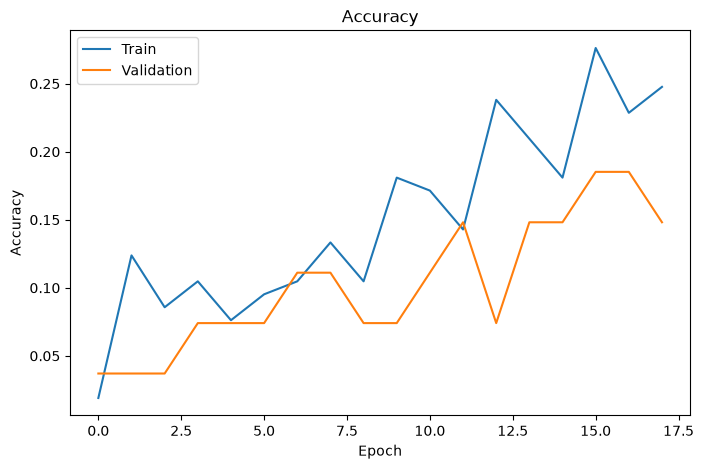

In [21]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"])

plt.plot(history.history["val_accuracy"])

plt.legend(

    ["Train","Validation"]
)

plt.title("Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.savefig("accuracy.png")

plt.show()

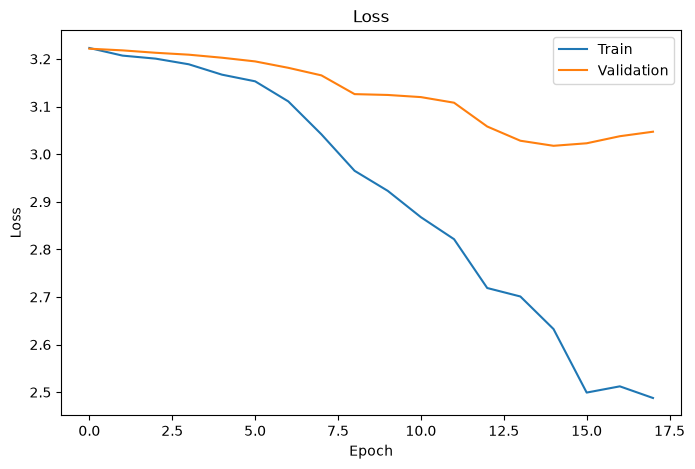

In [22]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"])

plt.plot(history.history["val_loss"])

plt.legend(

    ["Train","Validation"]
)

plt.title("Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.savefig("loss.png")

plt.show()

In [23]:
loss, accuracy = model.evaluate(

    X_test,

    y_test
)

print(

    "Test Accuracy:",

    accuracy
)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.1471 - loss: 2.7633
Test Accuracy: 0.14705882966518402


In [24]:
y_pred = model.predict(

    X_test
)

y_pred = np.argmax(

    y_pred,

    axis=1
)

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 700ms/step


In [25]:
print(

    classification_report(

        y_test,

        y_pred,

        target_names=encoder.classes_
    )
)

                           precision    recall  f1-score   support

                 Advocate       0.00      0.00      0.00         2
                     Arts       0.00      0.00      0.00         1
       Automation Testing       0.00      0.00      0.00         1
               Blockchain       0.00      0.00      0.00         1
         Business Analyst       0.00      0.00      0.00         1
           Civil Engineer       0.00      0.00      0.00         1
             Data Science       0.00      0.00      0.00         2
                 Database       0.00      0.00      0.00         2
          DevOps Engineer       0.00      0.00      0.00         1
         DotNet Developer       0.00      0.00      0.00         2
            ETL Developer       0.00      0.00      0.00         1
   Electrical Engineering       0.00      0.00      0.00         1
                       HR       0.14      1.00      0.25         2
                   Hadoop       0.00      0.00      0.00     

c:\Users\sajal sowna\Desktop\AI-Internship\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\sajal sowna\Desktop\AI-Internship\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\sajal sowna\Desktop\AI-Internship\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{me

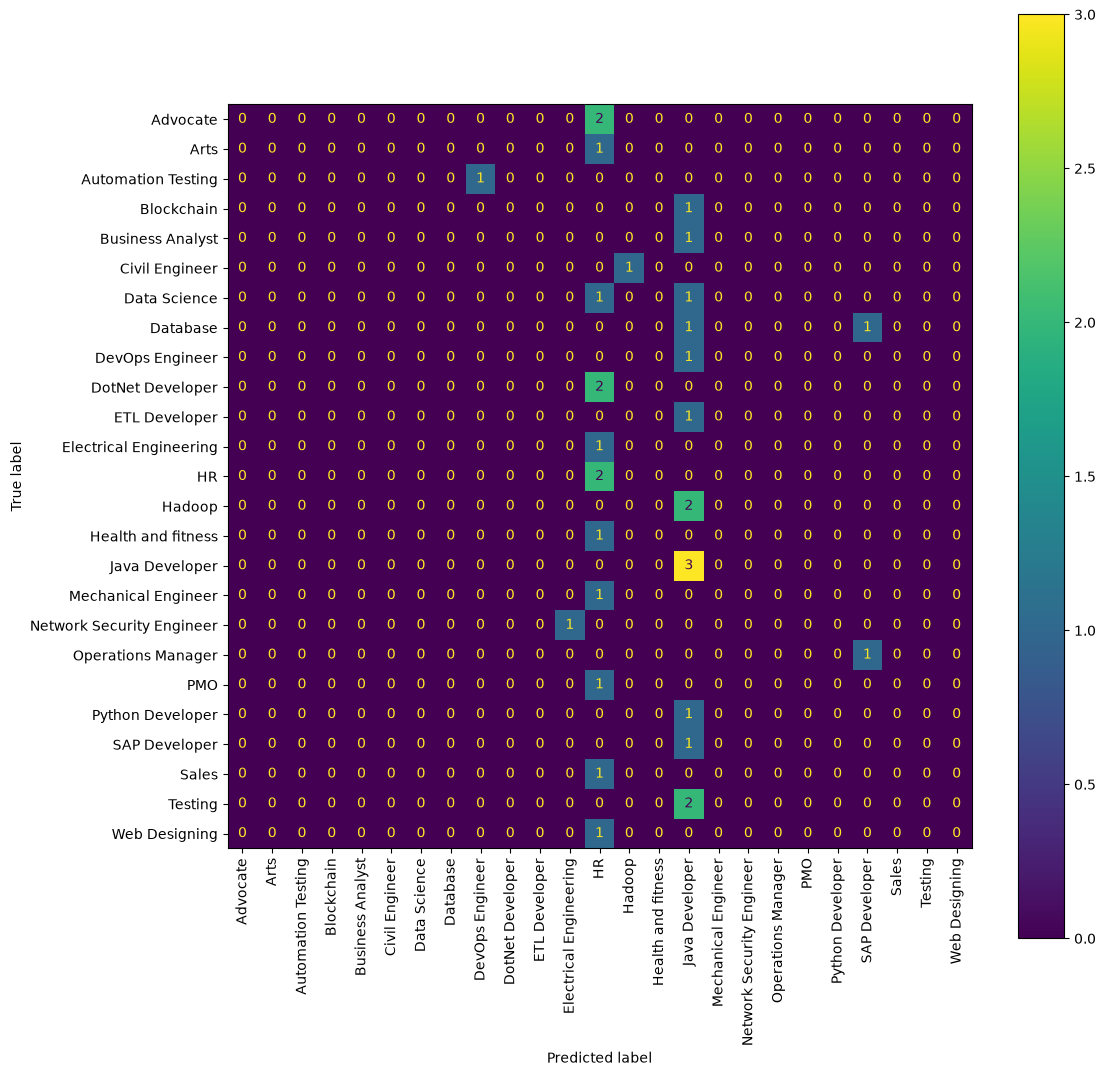

In [26]:
cm = confusion_matrix(

    y_test,

    y_pred
)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=encoder.classes_
)

fig, ax = plt.subplots(

    figsize=(12,12)
)

disp.plot(ax=ax)

plt.xticks(rotation=90)

plt.show()